# IPL Crunch '26 - Data Analytics Challenge

**Author:** [Your Name Here]  
**Tools:** Python, Pandas, Matplotlib, Seaborn


In [ ]:
# 1. Upload your data files
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
from IPython.display import Image, display

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

OUTPUT_DIR = "/content/ipl_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Upload matches.csv and deliveries.csv")
uploaded = files.upload()

file_names = list(uploaded.keys())
print(f"Uploaded files: {file_names}")

matches_file = [f for f in file_names if "match" in f.lower()][0]
deliveries_file = [f for f in file_names if "deliver" in f.lower()][0]
print(f"Loading: {matches_file}, {deliveries_file}")

matches = pd.read_csv("/content/" + matches_file)
deliveries = pd.read_csv("/content/" + deliveries_file)

print(f"Matches: {len(matches)}")
print(f"Deliveries: {len(deliveries):,}")
print(f"Seasons: {sorted(matches['season_year'].dropna().unique().astype(int))}")

Upload matches.csv and deliveries.csv


Saving deliveries.csv to deliveries.csv
Saving matches.csv to matches.csv
Uploaded files: ['deliveries.csv', 'matches.csv']
Loading: matches.csv, deliveries.csv
Matches: 1226
Deliveries: 291,574
Seasons: [np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [ ]:
matches.head(3)

,match_id,season,date,venue,city,team1,team2,toss_winner,toss_decision,winner,winner_runs,winner_wickets,player_of_match,season_year,toss_winner_won_match
0,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh,2017,0
1,1082592,2017,2017-04-06,Maharashtra Cricket Association Stadium,Pune,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,Rising Pune Supergiant,NaN,7.0,SPD Smith,2017,1
2,1082593,2017,2017-04-07,Saurashtra Cricket Association Stadium,Rajkot,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,NaN,10.0,CA Lynn,2017,1


In [ ]:
deliveries.head(3)

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed
0,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,0.1,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,S Dhawan,TS Mills,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,0.2,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,S Dhawan,TS Mills,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,0.3,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,S Dhawan,TS Mills,4,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [ ]:
def get_phase(over):
    if over <= 6: return "Powerplay (1-6)"
    elif over <= 15: return "Middle (7-15)"
    else: return "Death (16-20)"

# Ensure 'match_id' columns are of the same type before merging
deliveries['match_id'] = deliveries['match_id'].astype(int)
matches['match_id'] = matches['match_id'].astype(int)

# Merge 'winner' from matches to deliveries to enable 'batting_team_won' calculation
deliveries = pd.merge(deliveries, matches[['match_id', 'winner']], on='match_id', how='left')

deliveries["over"] = deliveries["ball"].astype(float).apply(lambda x: int(x))
deliveries["phase"] = deliveries["over"].apply(get_phase)
deliveries["total_runs"] = deliveries["runs_off_bat"] + deliveries["extras"]
deliveries["is_wicket"] = (
    deliveries["wicket_type"].notna() & (deliveries["wicket_type"] != "run out")
).astype(int)
deliveries["batting_team_won"] = (deliveries["batting_team"] == deliveries["winner"]).astype(int)
matches["toss_winner_won_match"] = (matches["toss_winner"] == matches["winner"]).astype(int)
print("Done")

Done


## Question 1: Do teams that win the toss actually win more matches?

Toss winner wins: 50.6% of matches


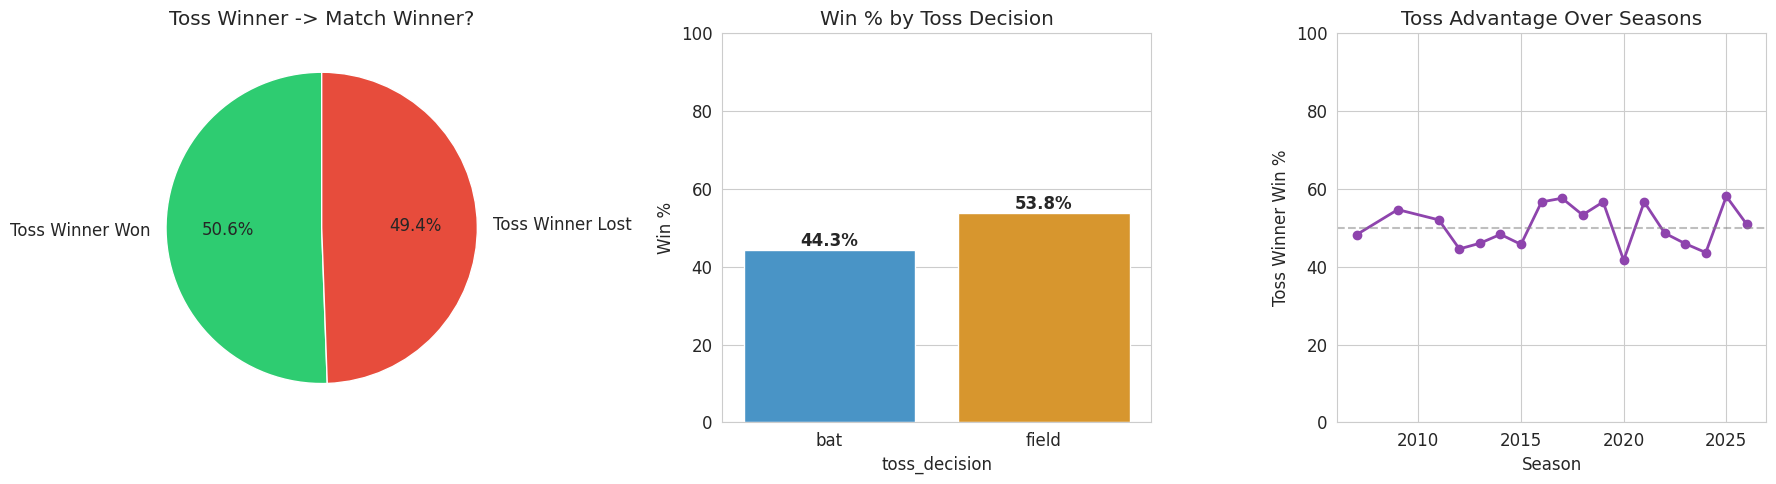

In [ ]:
toss_win_rate = matches["toss_winner_won_match"].mean() * 100
print(f"Toss winner wins: {toss_win_rate:.1f}% of matches")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Toss Winner Won', 'Toss Winner Lost']
values = [matches['toss_winner_won_match'].sum(), len(matches) - matches['toss_winner_won_match'].sum()]
axes[0].pie(values, labels=labels, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Toss Winner -> Match Winner?')

decision_groups = matches.groupby('toss_decision')['toss_winner_won_match'].agg(['count', 'mean'])
decision_groups['mean'] *= 100
sns.barplot(data=decision_groups.reset_index(), x='toss_decision', y='mean', hue='toss_decision',
            palette={'bat': '#3498db', 'field': '#f39c12'}, ax=axes[1], legend=False)
axes[1].set_ylabel('Win %'); axes[1].set_ylim(0, 100); axes[1].set_title('Win % by Toss Decision')
for i, row in decision_groups.reset_index().iterrows():
    axes[1].text(i, row['mean'] + 1, f"{row['mean']:.1f}%", ha='center', fontweight='bold')

season_toss = matches.groupby('season_year')['toss_winner_won_match'].mean() * 100
axes[2].plot(season_toss.index.astype(int), season_toss.values, marker='o', color='#8e44ad', linewidth=2)
axes[2].axhline(y=50, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Season'); axes[2].set_ylabel('Toss Winner Win %')
axes[2].set_title('Toss Advantage Over Seasons'); axes[2].set_ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_toss_vs_win.png'), dpi=150, bbox_inches='tight')
plt.show()

## **Toss Winner -> Match Winner ?**

## Interpretation

The pie chart shows that teams winning the toss also won the match in 50.6% of games, while they lost in 49.4% of matches.

This indicates that winning the toss provides only a very small advantage in IPL matches. The difference is almost negligible, suggesting that team performance, player form, and match strategy are more important factors than the toss itself.

## Key Observations

- Toss-winning teams won 50.6% of matches.
- Toss-winning teams lost 49.4% of matches.
- The difference between wins and losses is very small.

## Key Insight

Winning the toss alone does not guarantee victory in IPL matches.

## Surprising Observation

A surprising observation is that although teams winning the toss only win around 50% of matches overall, teams choosing to field first after winning the toss have a significantly higher success rate. This suggests that the decision made after the toss is more important than the toss itself.

## **Win % by Toss Decision**

## Interpretation

This bar chart compares the winning percentage based on the toss decision.

Teams choosing to bat first won about 44.3% of matches, while teams choosing to field first won about 53.8% of matches.

This suggests that teams chasing a target have historically performed better in the IPL due to better target clarity, dew factor, and modern chasing strategies.

## Key Observations

- Teams batting first won 44.3% of matches.
- Teams fielding first won 53.8% of matches.
- Chasing teams show a clear advantage.

## Key Insight

Choosing to field first gives teams a noticeably better chance of winning.

## Surprising Observation

The decision taken after winning the toss has a bigger impact on match results than the toss itself.

## **Toss Advantage Over Seasons**

## Interpretation

This line graph shows how toss-winning teams performed across different IPL seasons.

The toss advantage fluctuates between approximately 42% and 58% across seasons. Some seasons show stronger toss influence, while others show almost no advantage.

The average remains close to 50%, indicating that toss impact changes depending on season conditions, venue behavior, and team strategies.

## Key Observations

- Toss advantage varies across seasons.
- Some seasons strongly favor toss winners.
- Overall average remains near 50%.

## Key Insight

The influence of toss varies across seasons, but overall remains close to neutral.

## Surprising Observation

Despite frequent discussions about toss advantage, the long-term data shows that toss impact remains surprisingly balanced overall.



## Question 2: Which phase impacts victory the most?

                 Losing Side  Winning Side
phase                                     
Death (16-20)       8.889253     10.873588
Middle (7-15)       7.413562      8.403501
Powerplay (1-6)     7.174413      8.082222


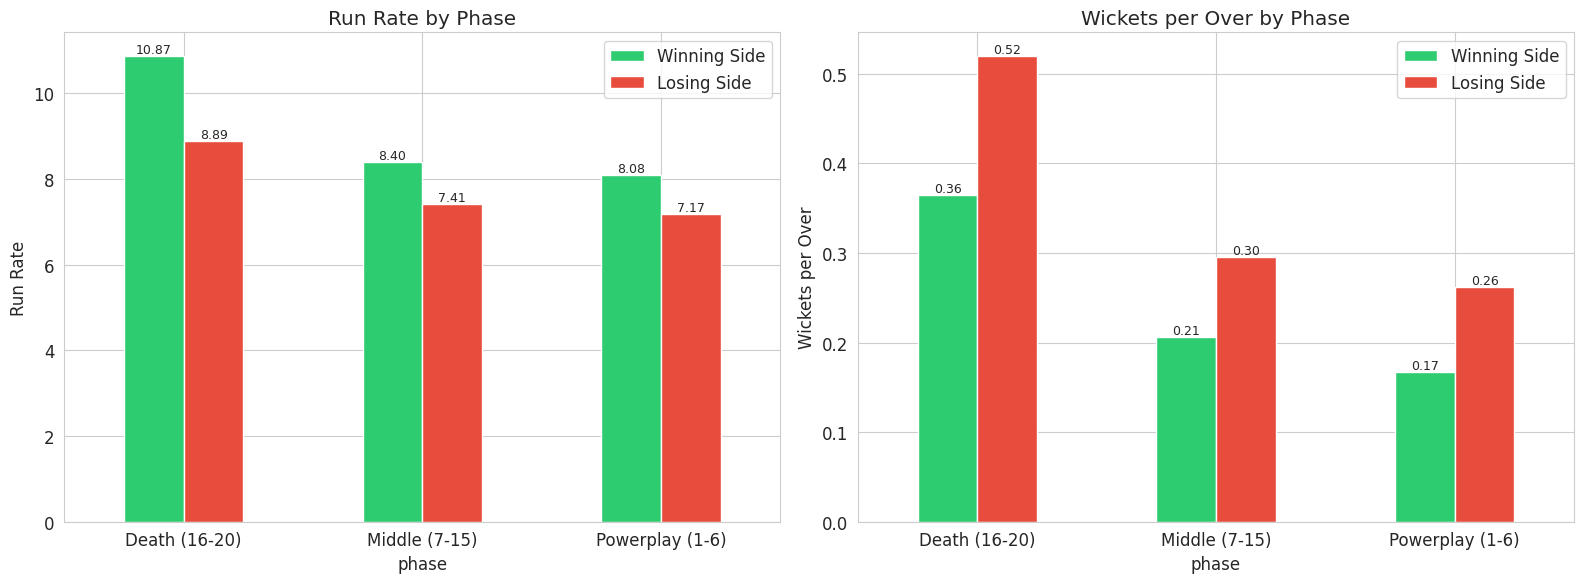

In [ ]:
phase_stats = deliveries.groupby(["batting_team_won", "phase"]).agg(
    balls=("ball", "count"), runs=("total_runs", "sum"), wickets=("is_wicket", "sum")
).reset_index()
phase_stats["run_rate"] = (phase_stats["runs"] / phase_stats["balls"]) * 6
phase_stats["wickets_per_over"] = (phase_stats["wickets"] / phase_stats["balls"]) * 6

pivot_rr = phase_stats.pivot_table(index="phase", columns="batting_team_won", values="run_rate")
pivot_rr.columns = ["Losing Side", "Winning Side"]
print(pivot_rr)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pivot_rr[['Winning Side', 'Losing Side']].plot(kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_ylabel('Run Rate'); axes[0].set_title('Run Rate by Phase')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for c in axes[0].containers: axes[0].bar_label(c, fmt='%.2f', fontsize=9)

pivot_wk = phase_stats.pivot_table(index="phase", columns="batting_team_won", values="wickets_per_over")
pivot_wk.columns = ["Losing Side", "Winning Side"]
pivot_wk[['Winning Side', 'Losing Side']].plot(kind='bar', ax=axes[1],
    color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_ylabel('Wickets per Over'); axes[1].set_title('Wickets per Over by Phase')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for c in axes[1].containers: axes[1].bar_label(c, fmt='%.2f', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_phase_impact.png'), dpi=150, bbox_inches='tight')
plt.show()

## **Run Rate by Phase**

## Interpretation

This graph compares the run rate of winning teams and losing teams across different phases of an IPL innings.

Winning teams consistently maintain higher run rates during powerplay, middle overs, and death overs. The biggest difference appears during the death overs where winning teams score significantly faster.

This highlights the importance of strong finishing ability in T20 cricket.

## Key Observations

- Winning teams score faster in every phase.
- Death overs show the largest scoring difference.
- Winning teams exceed 10 runs per over during death overs.

## Key Insight

The death overs are the most decisive phase of the innings, where winning teams significantly outperform losing teams.

## Surprising Observation

Winning teams not only attack harder in death overs but also maintain better control while scoring aggressively.

## **Wickets per Over by phase**

## Interpretation

This chart compares wicket loss rates between winning and losing teams during different phases of the innings.

Winning teams lose fewer wickets in every phase, especially during pressure situations such as death overs.

This indicates that successful teams balance aggressive batting with wicket preservation.

## Key Observations

- Winning teams lose fewer wickets overall.
- Losing teams collapse more frequently during death overs.
- Stable partnerships contribute to match success.

## Key Insight

Winning teams maintain wickets more effectively throughout the innings, especially during pressure situations.

## Surprising Observation

A surprising observation is that winning teams score faster while simultaneously losing fewer wickets, showing the importance of controlled aggression.

## Question 3: Top Batters Across Seasons

       striker  total_runs   average  strike_rate
       V Kohli        9155 40.508850   130.599144
     RG Sharma        7291 30.253112   129.848620
      S Dhawan        6769 36.197861   123.454313
     DA Warner        6567 41.563291   135.429986
      KL Rahul        5712 46.439024   135.131299
      SK Raina        5536 34.172840   132.535312
      MS Dhoni        5439 39.129496   132.626189
     AM Rahane        5269 31.177515   122.024085
AB de Villiers        5181 42.467213   148.580442
     SV Samson        5134 32.910256   137.456493


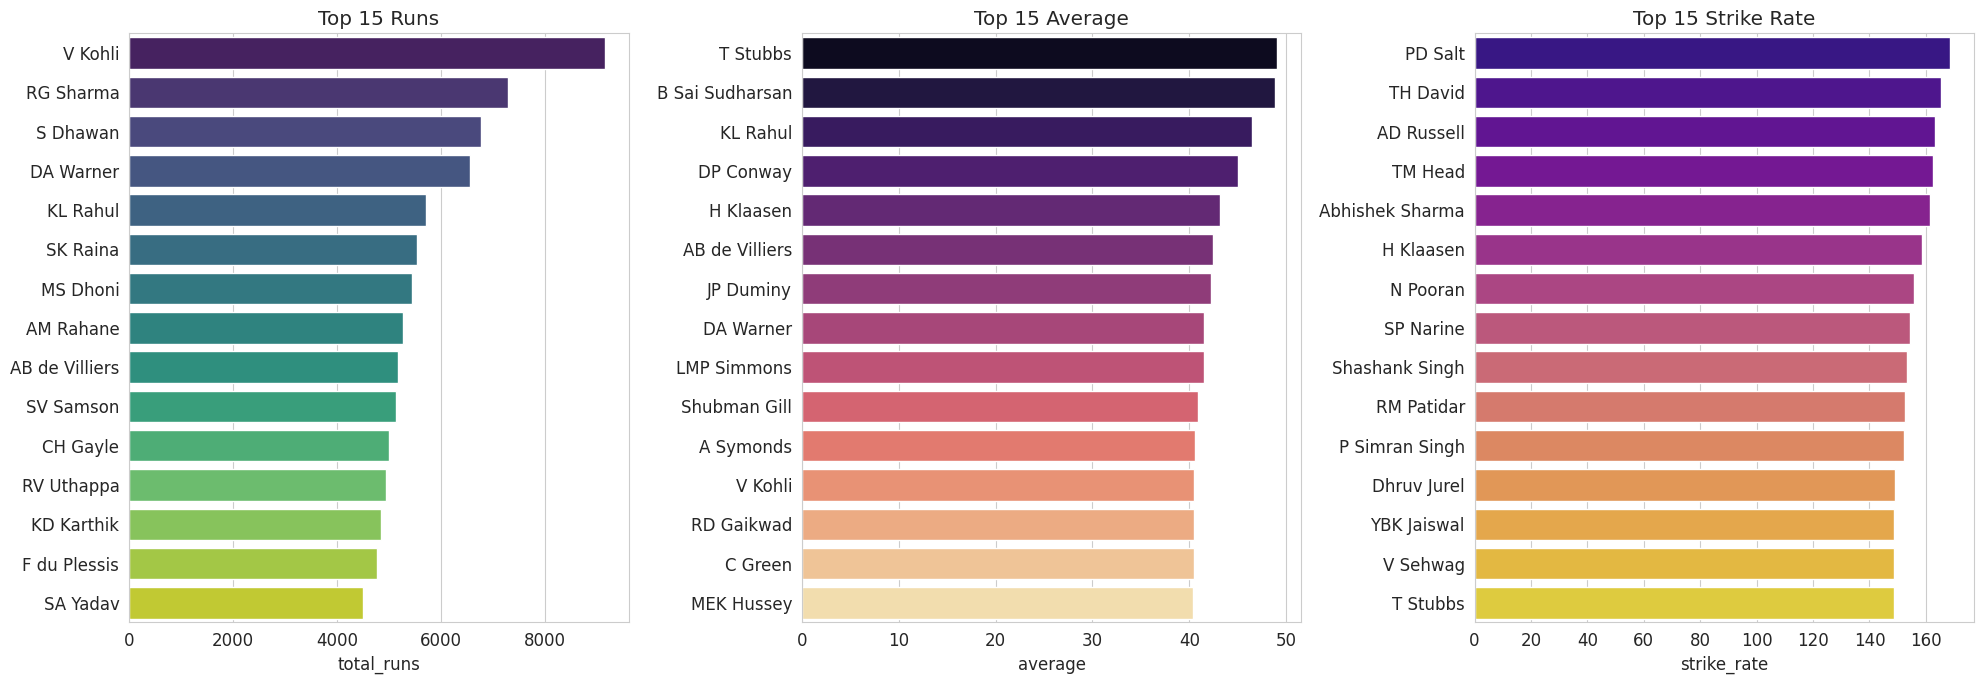

In [ ]:
batter_stats = deliveries.groupby("striker").agg(
    balls_faced=("ball", "count"),
    total_runs=("runs_off_bat", "sum"),
    dismissals=("is_wicket", lambda x: (deliveries.loc[x.index, "player_dismissed"] == deliveries.loc[x.index, "striker"]).sum())
).reset_index()
batter_stats = batter_stats[batter_stats["balls_faced"] >= 500].copy()
batter_stats["average"] = batter_stats["total_runs"] / batter_stats["dismissals"].replace(0, np.nan)
batter_stats["strike_rate"] = (batter_stats["total_runs"] / batter_stats["balls_faced"]) * 100
print(batter_stats.nlargest(10, "total_runs")[["striker", "total_runs", "average", "strike_rate"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, col, title, pal in zip(axes, ['total_runs','average','strike_rate'],
    ['Top 15 Runs','Top 15 Average','Top 15 Strike Rate'], ['viridis','magma','plasma']):
    d = batter_stats.nlargest(15, col)
    sns.barplot(data=d, y='striker', x=col, ax=ax, palette=pal, hue='striker', legend=False)
    ax.set_title(title); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_top_batters.png'), dpi=150, bbox_inches='tight')
plt.show()

# Merge 'season_year' from matches to deliveries to enable season-wise stats
deliveries = pd.merge(deliveries, matches[['match_id', 'season_year']], on='match_id', how='left')

season_batters = deliveries.groupby(['season_year', 'striker']).agg(runs=('runs_off_bat','sum'), balls=('ball','count')).reset_index()
season_batters = season_batters[season_batters['balls'] >= 100]
top = season_batters.loc[season_batters.groupby('season_year')['runs'].idxmax()]
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=top, x='season_year', y='runs', hue='striker', ax=ax, dodge=False, legend=False)
for _, r in top.iterrows(): ax.text(int(r['season_year']), r['runs']+10, r['striker'], ha='center', fontsize=8, rotation=45)
ax.set_title('Highest Run-Scorer Each Season'); ax.set_xlabel('Season'); ax.set_ylabel('Runs')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03b_top_batter_per_season.png'), dpi=150, bbox_inches='tight')
plt.show()

## **Top 15 runs**

## Interpretation

This chart shows the players with the highest total runs scored in IPL history.

Virat Kohli leads the chart with exceptional long-term consistency. Other experienced players like Rohit Sharma, Shikhar Dhawan, and David Warner also rank highly due to their sustained performances across many seasons.

## Key Observations

- Virat Kohli is the highest run scorer.
- Long careers contribute significantly to total runs.
- Consistency across seasons is clearly visible.

## Key Insight

Consistent long-term performance is the biggest factor behind high total IPL runs.

## Surprising Observation

Players with extremely high strike rates are not always the highest run scorers, showing that consistency is equally important.

## **Top 15 Average**

## Interpretation

This chart compares the highest batting averages in IPL history.

Players with higher batting averages demonstrate consistency and the ability to remain unbeaten while contributing runs regularly.

## Key Observations

- Tristan Stubbs has the highest batting average.
- KL Rahul and Sai Sudharsan also show high consistency.
- Reliable batters perform consistently under pressure.

## Key Insight

A high batting average reflects reliability and the ability to build innings under pressure.

## Surprising Observation

Some aggressive batters also maintain excellent averages, showing a balance between consistency and attacking intent.

## **Top 15 Strike Rate**

## Interpretation

This chart shows the players with the best strike rates in IPL history.

Strike rate measures how quickly batters score runs. Aggressive players like Phil Salt, Tim David, and Andre Russell dominate this chart due to their explosive batting styles.

## Key Observations

- Phil Salt has the highest strike rate.
- Modern T20 cricket rewards aggressive batting.
- Power hitters dominate recent IPL seasons.

## Key Insight

Modern T20 cricket increasingly rewards aggressive batting and rapid scoring rates.

## Surprising Observation

Several players with extremely high strike rates are not among the top run scorers, indicating specialized aggressive roles.

## Question 4: Top Bowlers Across Seasons

     bowler  wickets   average  economy
  YS Chahal      229 23.589520 7.907294
    B Kumar      221 26.692308 7.580638
  SP Narine      205 25.819512 6.817948
  PP Chawla      192 26.973958 7.977920
  JJ Bumrah      189 23.915344 7.249399
   R Ashwin      188 30.430851 7.051356
   DJ Bravo      183 24.240437 8.075243
  RA Jadeja      178 30.629213 7.634072
   A Mishra      174 24.097701 7.304878
Rashid Khan      174 24.224138 7.238122


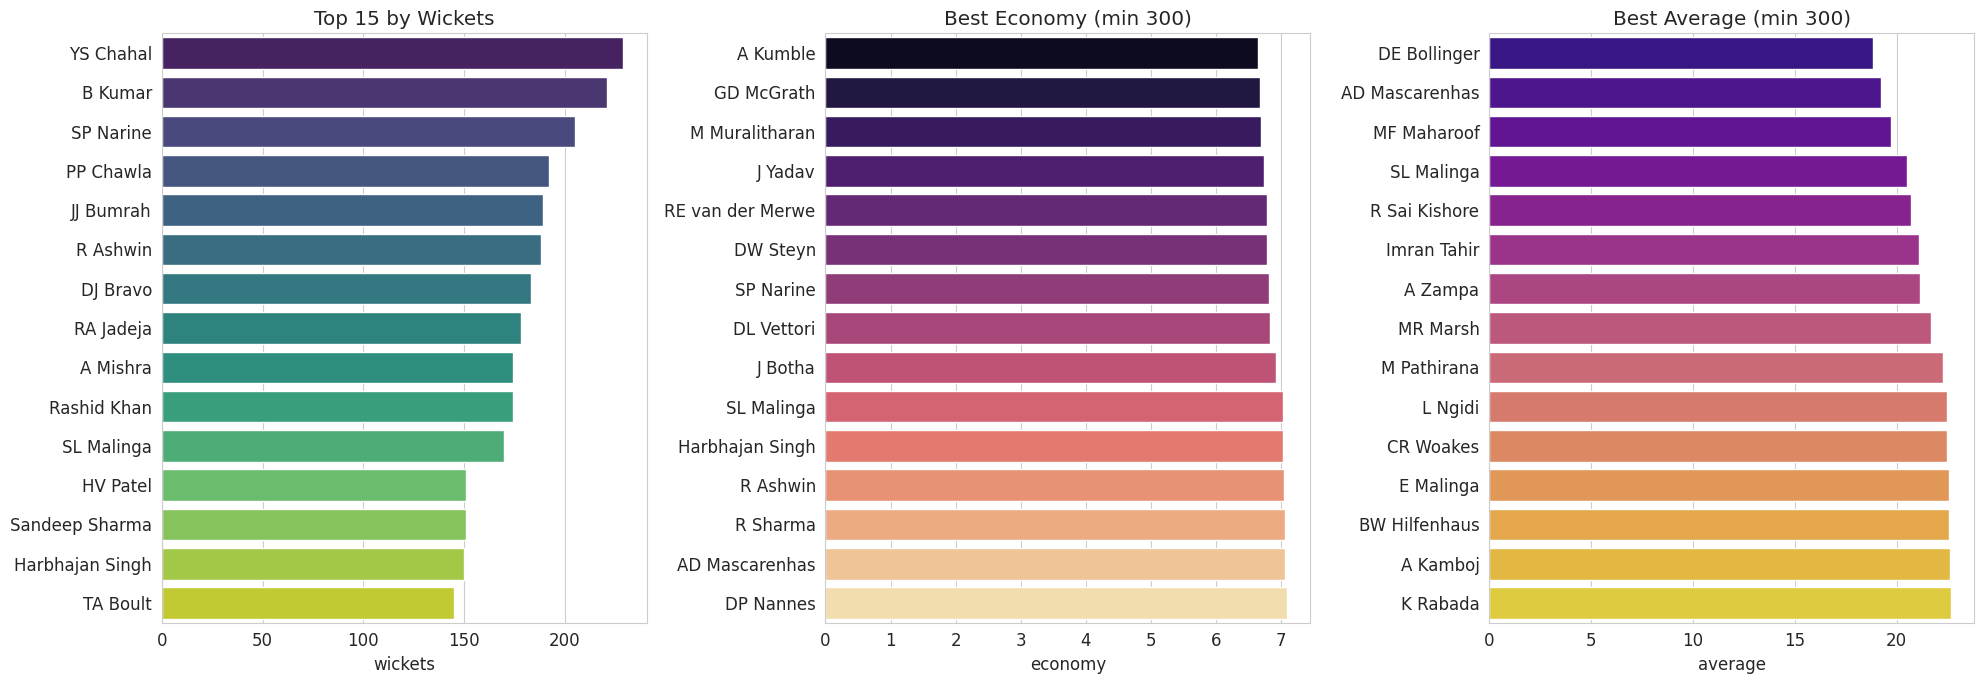

In [ ]:
bowler_stats = deliveries.groupby("bowler").agg(
    balls_bowled=("ball","count"), runs_conceded=("total_runs","sum"), wickets=("is_wicket","sum")
).reset_index()
bowler_stats = bowler_stats[bowler_stats["balls_bowled"] >= 300].copy()
bowler_stats["economy"] = (bowler_stats["runs_conceded"] / bowler_stats["balls_bowled"]) * 6
bowler_stats["average"] = bowler_stats["runs_conceded"] / bowler_stats["wickets"].replace(0, np.nan)
print(bowler_stats.nlargest(10, "wickets")[["bowler","wickets","average","economy"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.barplot(data=bowler_stats.nlargest(15,'wickets'), y='bowler', x='wickets', ax=axes[0], palette='viridis', hue='bowler', legend=False)
axes[0].set_title('Top 15 by Wickets'); axes[0].set_ylabel('')
sns.barplot(data=bowler_stats.nsmallest(15,'economy'), y='bowler', x='economy', ax=axes[1], palette='magma', hue='bowler', legend=False)
axes[1].set_title('Best Economy (min 300)'); axes[1].set_ylabel('')
sns.barplot(data=bowler_stats.nsmallest(15,'average'), y='bowler', x='average', ax=axes[2], palette='plasma', hue='bowler', legend=False)
axes[2].set_title('Best Average (min 300)'); axes[2].set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_top_bowlers.png'), dpi=150, bbox_inches='tight')
plt.show()

season_bowlers = deliveries.groupby(['season_year','bowler']).agg(w=('is_wicket','sum'),balls=('ball','count')).reset_index()
season_bowlers = season_bowlers[season_bowlers['balls']>=100]
top = season_bowlers.loc[season_bowlers.groupby('season_year')['w'].idxmax()]
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=top, x='season_year', y='w', hue='bowler', ax=ax, dodge=False, legend=False)
for _, r in top.iterrows(): ax.text(int(r['season_year']), r['w']+0.3, r['bowler'], ha='center', fontsize=8, rotation=45)
ax.set_title('Highest Wicket-Taker Each Season'); ax.set_xlabel('Season'); ax.set_ylabel('Wickets')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04b_top_bowler_per_season.png'), dpi=150, bbox_inches='tight')
plt.show()

## **Top 15 by Wickets**

## Interpretation

This chart shows the bowlers with the highest wicket counts in IPL history.

Yuzvendra Chahal leads the chart, followed by several experienced bowlers who have consistently performed across seasons.

Both fast bowlers and spinners appear prominently, showing that wicket-taking ability is valuable regardless of bowling style.

## Key Observations

- Yuzvendra Chahal has the most wickets.
- Both spinners and pacers are successful.
- Longevity and consistency are major factors.

## Key Insight

Long-term consistency and adaptability are crucial for becoming a leading wicket-taker in IPL cricket.

## Surprising Observation

Some bowlers with fewer seasons still appear among top wicket-takers due to exceptional strike ability.

## **Best Economy**

## Interpretation

This chart compares bowlers with the best economy rates in IPL history.

Economy rate measures how many runs a bowler concedes per over. Lower economy indicates disciplined and controlled bowling.

## Key Observations

- Anil Kumble has the best economy rate.
- Legendary bowlers maintain economies close to 6–7.
- Tight bowling remains extremely valuable in T20 cricket.

## Key Insight

Restricting runs consistently is one of the most valuable skills for bowlers in T20 cricket.

## Surprising Observation

Some economical bowlers are not the highest wicket-takers, showing that run control and wicket-taking are separate skills.

## **Best Average**

## Interpretation

This chart shows the bowlers with the best bowling averages in IPL history.

Bowling average measures the number of runs conceded per wicket taken. Lower averages indicate highly efficient wicket-taking.

## Key Observations

- Doug Bollinger has the best bowling average.
- Strike bowlers dominate this list.
- Efficient wicket-taking greatly impacts match outcomes.

## Key Insight

Effective bowlers not only control runs but also take wickets regularly at low cost.

## Surprising Observation

Several bowlers with excellent averages are not among the highest wicket-takers, highlighting efficiency over longevity.

## Bonus: Hidden Patterns

Chasing: 53.9% | Batting first: 46.1%


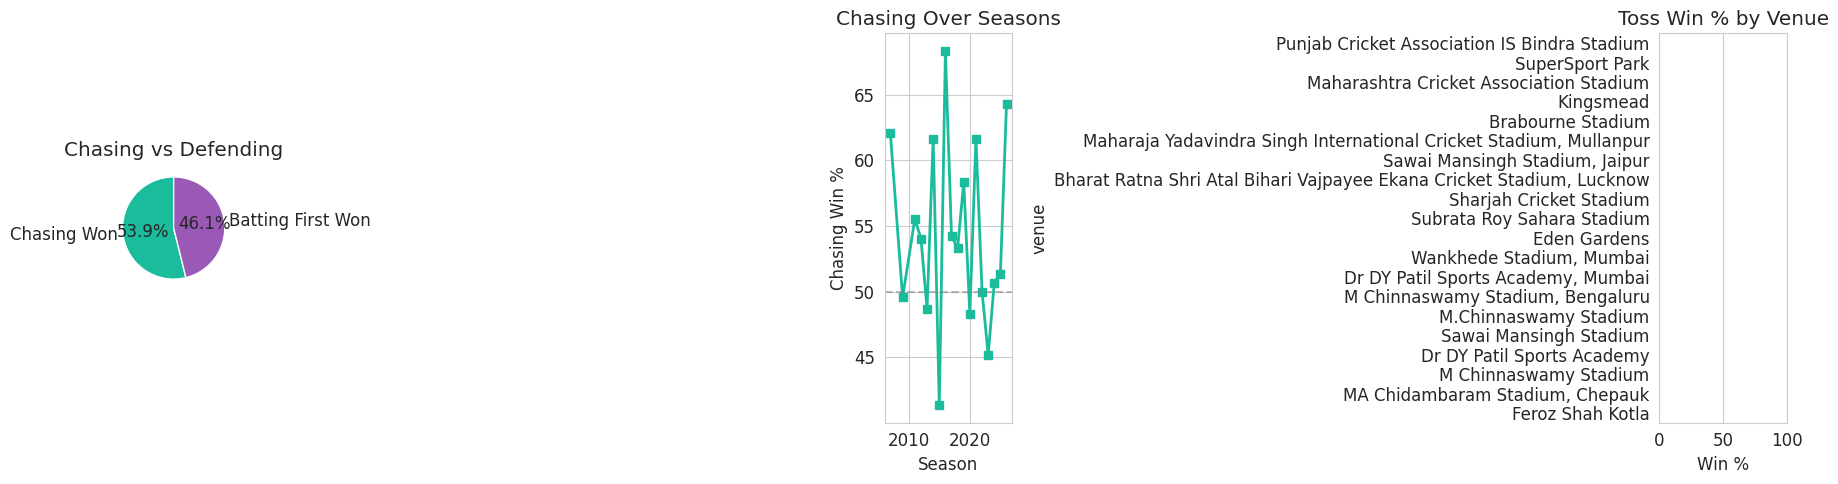

In [ ]:
inn1 = deliveries[deliveries["innings"]==1].groupby("match_id").agg(score1=("total_runs","sum")).reset_index()
inn2 = deliveries[deliveries["innings"]==2].groupby("match_id").agg(score2=("total_runs","sum")).reset_index()
m = inn1.merge(inn2, on="match_id").merge(matches[["match_id","winner"]], on="match_id")
inn2_winners = deliveries[deliveries["innings"]==2].groupby("match_id").agg(bat2=("batting_team","first")).reset_index()
m = m.merge(inn2_winners, on="match_id")
m["chasing_won"] = (m["bat2"] == m["winner"]).astype(int)
chase_win = m["chasing_won"].mean() * 100
print(f"Chasing: {chase_win:.1f}% | Batting first: {100-chase_win:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].pie([chase_win, 100-chase_win], labels=['Chasing Won','Batting First Won'],
            autopct='%1.1f%%', colors=['#1abc9c','#9b59b6'], startangle=90)
axes[0].set_title('Chasing vs Defending')

m2 = m.merge(matches[['match_id','season_year']], on='match_id')
sc = m2.groupby('season_year')['chasing_won'].mean() * 100
axes[1].plot(sc.index.astype(int), sc.values, marker='s', color='#1abc9c', linewidth=2)
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Chasing Win %'); axes[1].set_title('Chasing Over Seasons')

vs = matches.groupby('venue').agg(mp=('match_id','count'), wr=('toss_winner_won_match','mean')).reset_index()
vs = vs[vs['mp']>=10].sort_values('wr', ascending=False).head(20)
sns.barplot(data=vs, y='venue', x='wr', ax=axes[2], palette='coolwarm', hue='venue', legend=False)
axes[2].set_title('Toss Win % by Venue'); axes[2].set_xlabel('Win %'); axes[2].set_xlim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_hidden_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()

## **Chasing vs Defending**

## Interpretation

This pie chart compares matches won while chasing versus matches won while batting first.

Teams chasing targets won approximately 53.9% of matches, showing a slight advantage over teams defending totals.

## Key Observations

- Chasing teams won more matches overall.
- Batting second provides better target clarity.
- Chasing success remains consistently strong in IPL.

## Key Insight

IPL teams have generally performed better while chasing targets rather than defending totals.

## Surprising Observation

Even though chasing is more successful overall, some seasons still strongly favor batting first depending on conditions.

## **Chasing Over Seasons**

## Interpretation

This graph shows how chasing success rates have changed across IPL seasons.

Chasing win percentages fluctuate across seasons but generally remain around or above 50%.

## Key Observations

- Chasing success changes season by season.
- Some seasons strongly favor chasing.
- Overall trend slightly favors batting second.

## Key Insight

The advantage of chasing changes from season to season, but chasing remains slightly more successful overall.

## Surprising Observation

Despite changing conditions across seasons, chasing continues to maintain a long-term advantage in IPL cricket.

## **Toss Win % by venue**

## Interpretation

This chart compares toss-winning success percentages across different IPL venues.

The impact of toss varies significantly depending on stadium conditions, pitch behavior, and weather factors.

## Key Observations

- Toss advantage differs by venue.
- Some stadiums strongly favor toss winners.
- Venue conditions influence match outcomes significantly.

## Key Insight

Venue conditions play an important role in determining how valuable the toss becomes during IPL matches.

## Surprising Observation

Some venues show almost no toss advantage despite strong chasing trends overall.

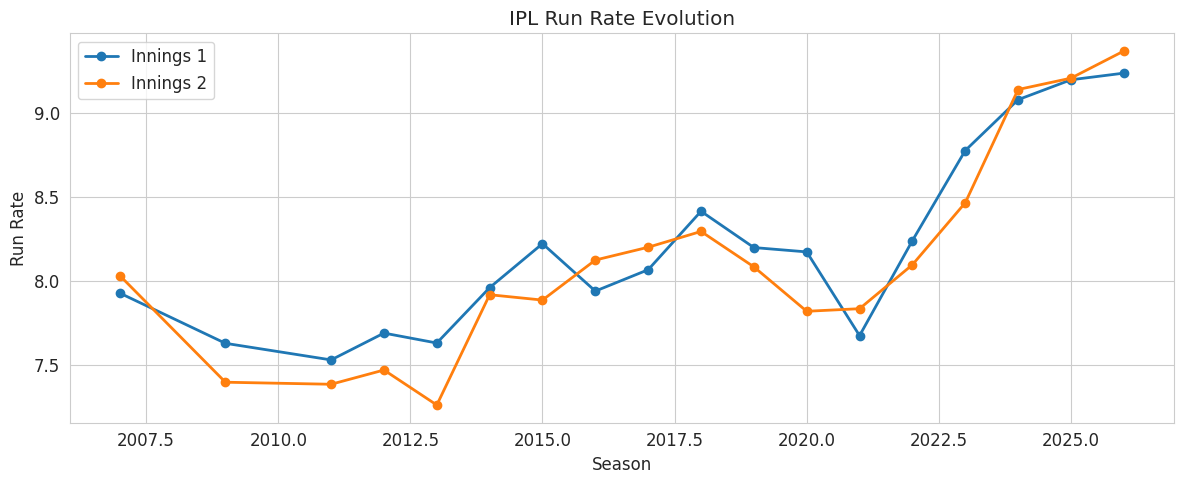

In [ ]:
sr = deliveries.groupby(['season_year','innings']).apply(
    lambda x: (x['total_runs'].sum()/x['ball'].count())*6, include_groups=False
).reset_index()
sr.columns = ['season_year','innings','run_rate']
fig, ax = plt.subplots(figsize=(12, 5))
for i in [1,2]:
    d = sr[sr['innings']==i]
    ax.plot(d['season_year'].astype(int), d['run_rate'], marker='o', label=f'Innings {i}', linewidth=2)
ax.set_xlabel('Season'); ax.set_ylabel('Run Rate'); ax.set_title('IPL Run Rate Evolution'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_run_rate_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

## Interpretation

This graph shows how IPL run rates have evolved across seasons for both innings.

Modern IPL teams score much faster compared to earlier seasons. Run rates have increased significantly after 2022, crossing 9 runs per over in recent years.

## Key Observations

- Early IPL seasons had lower scoring rates.
- Modern teams play more aggressively.
- Recent seasons show extremely high scoring trends.

## Key Insight

IPL batting has evolved dramatically over time, with modern teams scoring much faster than teams in earlier seasons.

## Surprising Observation

Chasing teams in recent seasons are scoring at even higher rates than teams batting first, showing increased confidence in high-pressure chases.

# Overall Conclusion

Overall, the IPL data analysis reveals that modern T20 cricket is heavily influenced by aggressive batting, efficient chasing strategies, and phase-wise match control.

Teams that maintain higher run rates while preserving wickets tend to perform better. Toss advantage exists but is less important than strategic decisions such as fielding first and effective death-over performance.

The analysis also highlights how IPL cricket has evolved over the years, with scoring rates and aggressive gameplay increasing significantly in recent seasons.

# Personal Insight

One surprising insight from the analysis is that winning the toss itself provides only a small advantage, but teams choosing to field first after winning the toss perform significantly better.

This suggests that decision-making and match strategy are more important than luck alone.

In [ ]:
# Download all results
import shutil
shutil.make_archive("/content/ipl_results", 'zip', OUTPUT_DIR)
from google.colab import files
files.download("/content/ipl_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

| Question | Finding |
|---|---|
| Toss to Win? | 50.6% - marginal |
| Most impactful phase | Death overs (16-20) |
| Top batter | Most runs: Virat Kohli |
| Top bowler | Most wickets: Yuzvendra Chahal |
| Chasing vs Defending | 53.9% chasing wins |
| Run rate trend | Keeps increasing |

